Evaluation Graphs for ANN

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.event_detection import build_detector, collect_default_data_paths, split_train_test
from src.event_detection_pipeline.model_io import load_detector, save_detector
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc as calc_auc,
    precision_recall_curve,
    average_precision_score,
)

In [2]:
data_dir = ROOT / 'src' / 'data'
paths = collect_default_data_paths(data_dir)
train_paths, test_paths = split_train_test(paths)

print(f'Loaded {len(paths)} SCADA files')
print(f'Train files: {len(train_paths)} | Test files: {len(test_paths)}')

Loaded 40 SCADA files
Train files: 28 | Test files: 12


In [3]:
# confusion matrix for event detection
history = 5
epochs = 12
batch_size = 256
learning_rate = 1e-3

candidate_hidden_sizes = [
    (32,),
    (64, 32),
    (128, 64),
    (128, 64, 32),
]

In [4]:
for hidden_sizes in candidate_hidden_sizes:
    candidate_detector = build_detector(
        train_paths,
        history=history,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        hidden_sizes=hidden_sizes,
    )

    save_detector(candidate_detector, directory=f"../results/2026-06-29/detector_{'-'.join(map(str, hidden_sizes))}")


All files saved to /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_32/

All files saved to /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_64-32/

All files saved to /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64/

All files saved to /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64-32/


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.event_detection_pipeline.evaluation import (
    plot_roc_curve_event_detection,
    plot_roc_curve_chlorine_prediction,
    plot_precision_recall_curve,
)


def plot_metrics(result, title_prefix="", chlorine_indices=None):
    if chlorine_indices is None:
        chlorine_indices = [0, 1, 2]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Confusion Matrix
    cm = confusion_matrix(
        result.event_flags.astype(bool),
        result.alarms.astype(bool),
        labels=[False, True],
        normalize="all",
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Event"],
    )
    disp.plot(
        ax=axes[0, 0],
        colorbar=False,
        values_format=".2f",
    )
    axes[0, 0].set_title(f"{title_prefix}Confusion Matrix")

    # 2. Event detection ROC
    plot_roc_curve_event_detection(
        result,
        title=f"{title_prefix}Event Detection ROC",
        ax=axes[0, 1],
    )

    # 3. Chlorine prediction ROC
    plot_roc_curve_chlorine_prediction(
        result,
        chlorine_indices=chlorine_indices,
        title=f"{title_prefix}Chlorine Prediction ROC",
        ax=axes[1, 0],
    )

    # 4. Precision-Recall curve
    plot_precision_recall_curve(
        result,
        title=f"{title_prefix}Precision-Recall Curve",
        ax=axes[1, 1],
    )

    plt.tight_layout()
    plt.show()

    return fig, axes


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64/
{'precision': 0.08253968253968254, 'accuracy': 0.6892430278884463, 'probability_of_detection': 0.5306122448979592, 'recall': 0.5306122448979592, 'false_alarm_rate': 0.30261780104712044, 'detection_latency_seconds': -225000.0, 'alarms': 315}


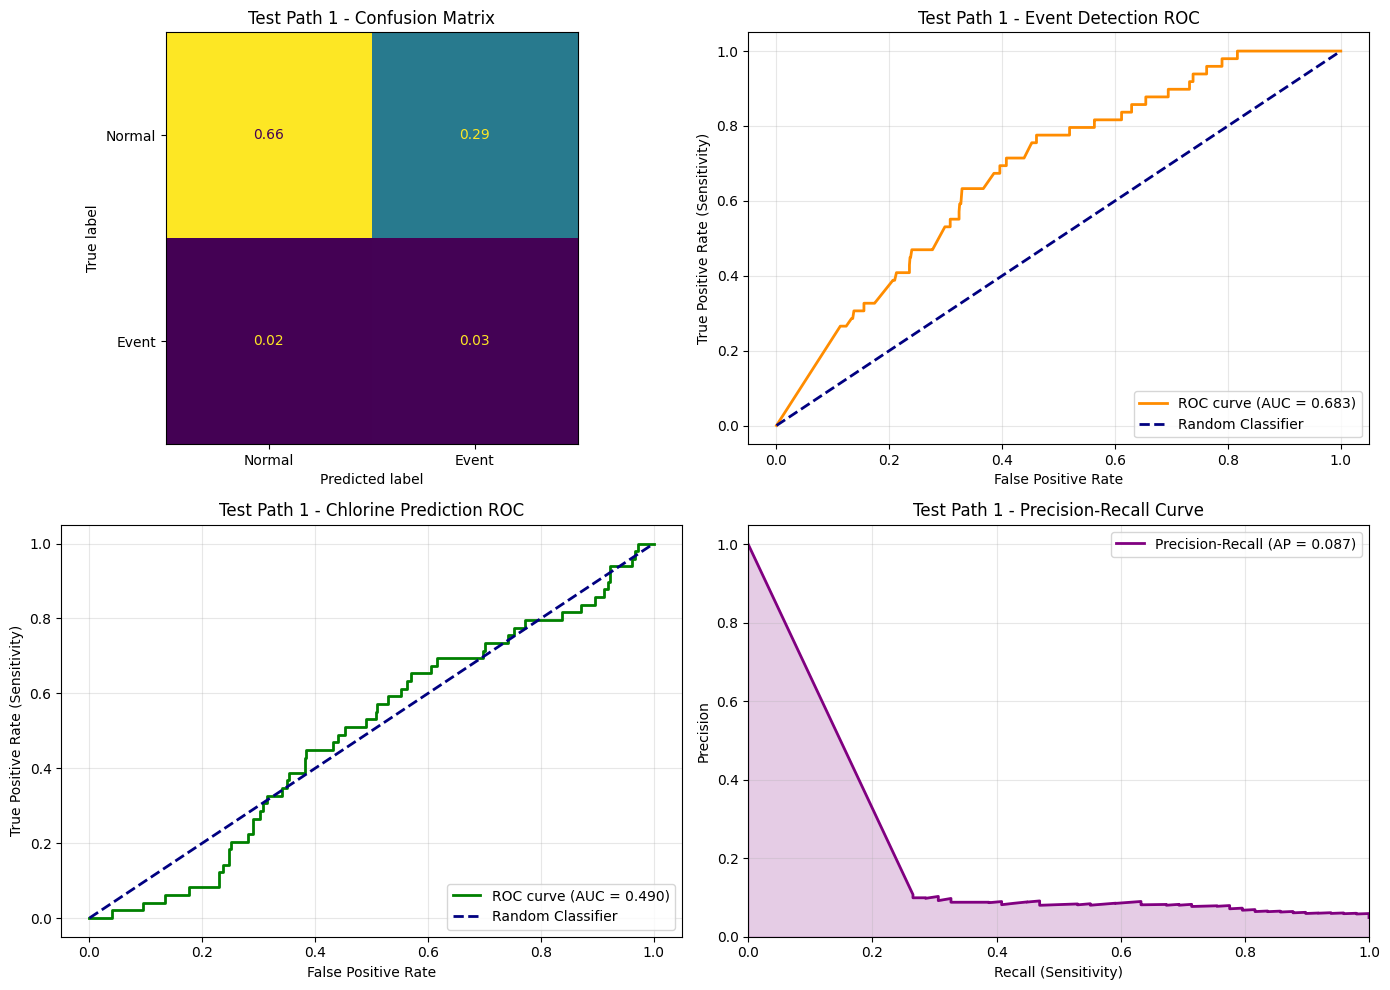

In [6]:
detector = load_detector(
        directory=f"../results/2026-06-29/detector_128-64",
        device="mps",
    )

results = detector.detect(test_paths[1])

summary = results.summary()
print(summary)

fig, axes = plot_metrics(
    results,
    title_prefix="Test Path 1 - ",
    chlorine_indices=[0, 1, 2],
)


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_32/
Results for detector with hidden sizes: 32


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_no_cont17.npz,0.069832,0.644422,0.510204,0.510204,0.348691,-225000.0,358
scada_data_no_cont18.npz,0.113208,0.787849,0.489796,0.489796,0.196859,-221400.0,212
scada_data_no_cont19.npz,0.053097,0.548805,0.489796,0.489796,0.448168,-160200.0,452


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.078712,0.660359,0.496599,0.496599,0.331239,-202200.000000,340.666667
std,0.031023,0.120316,0.011783,0.011783,0.126560,36417.578173,120.935244


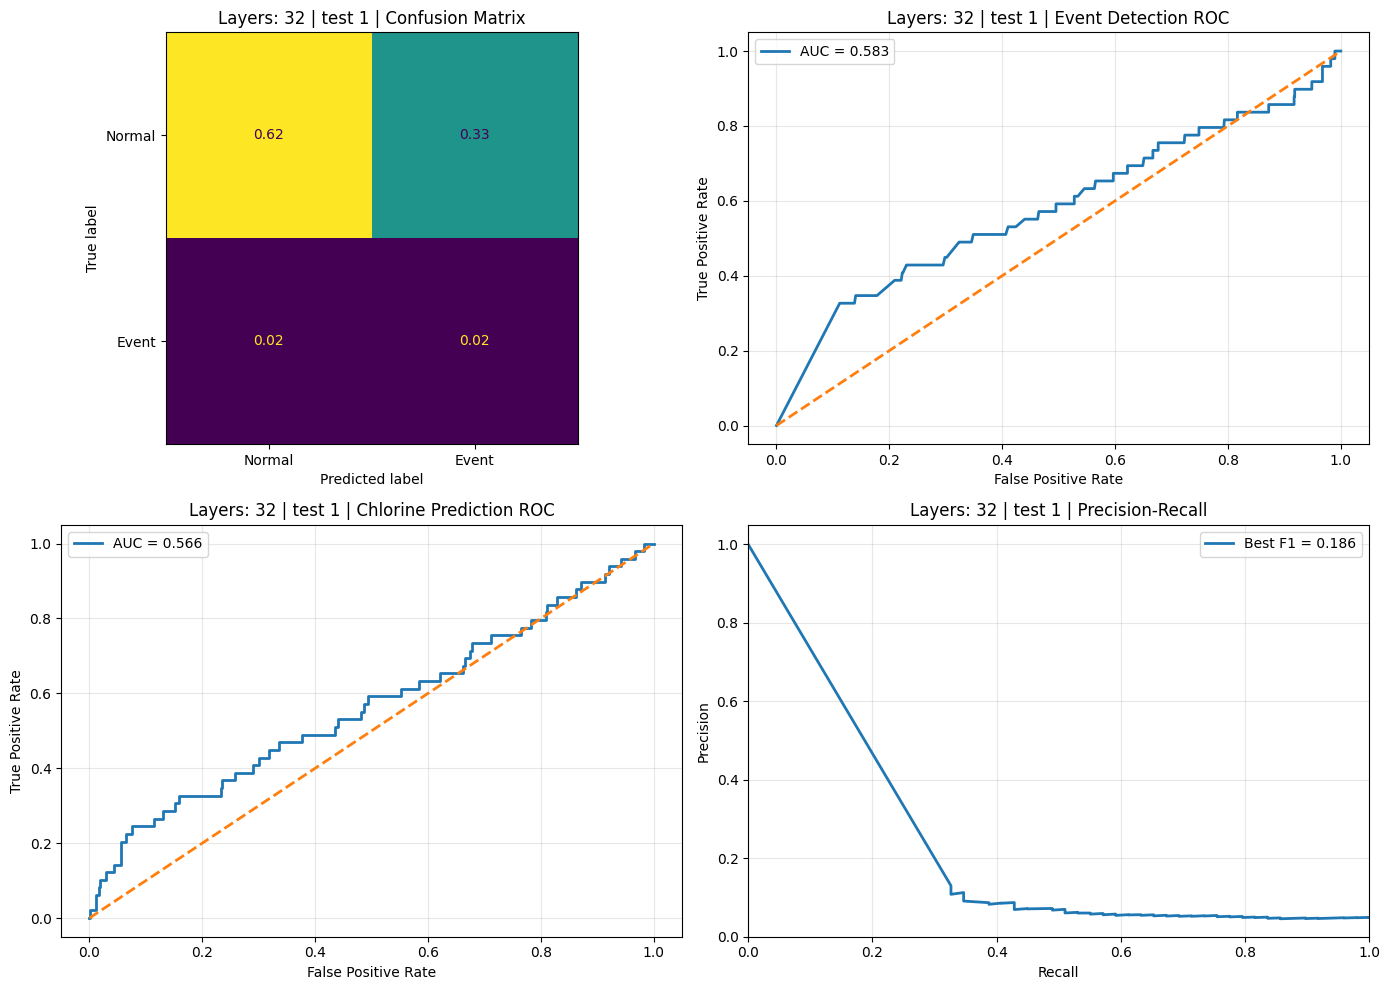

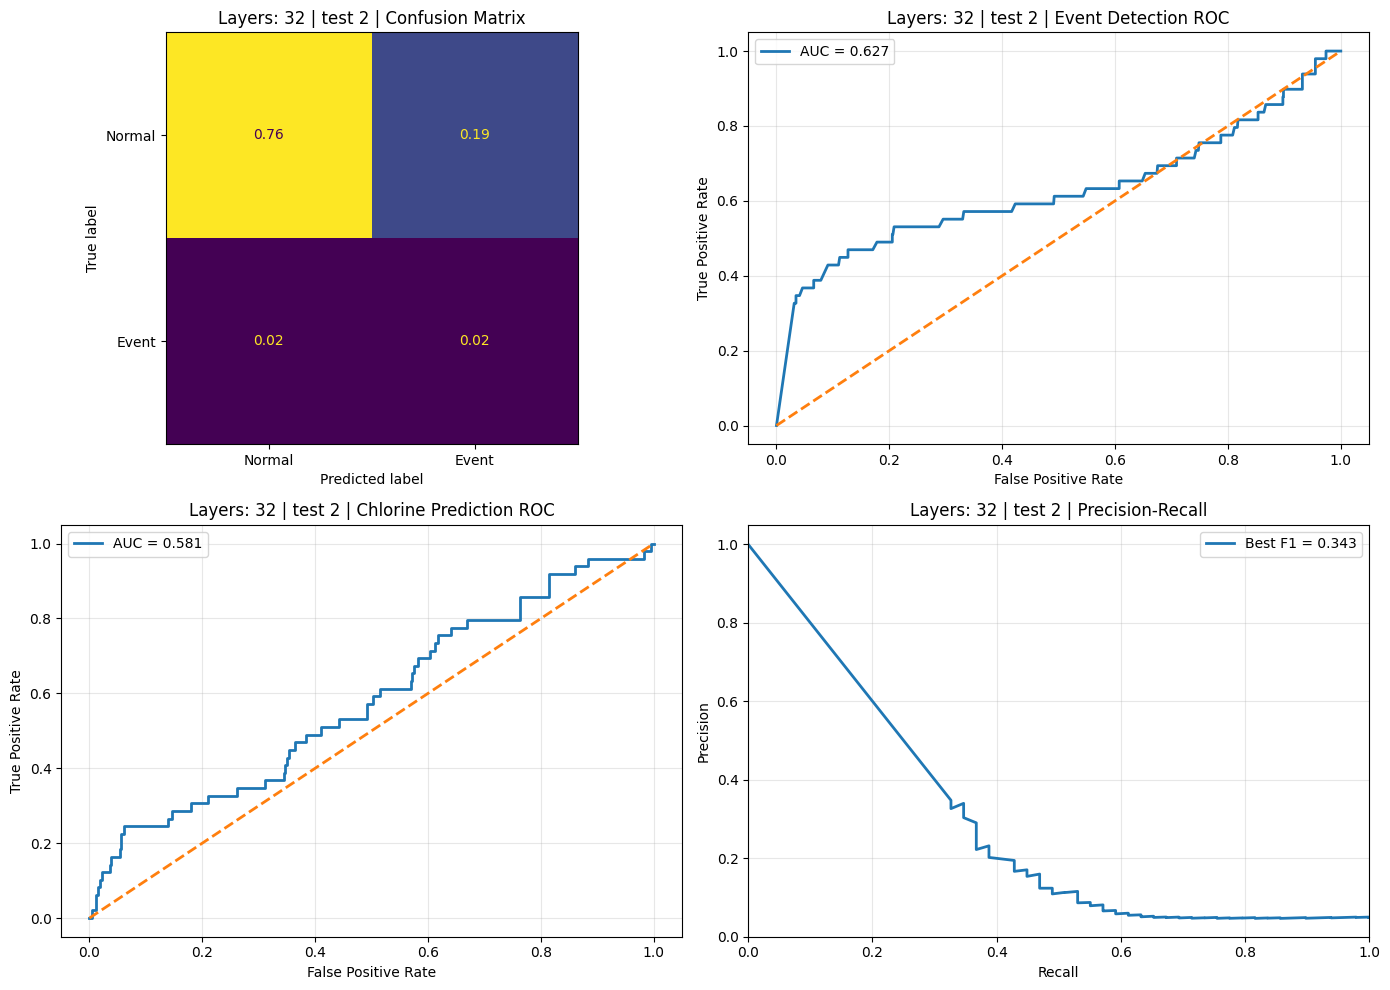

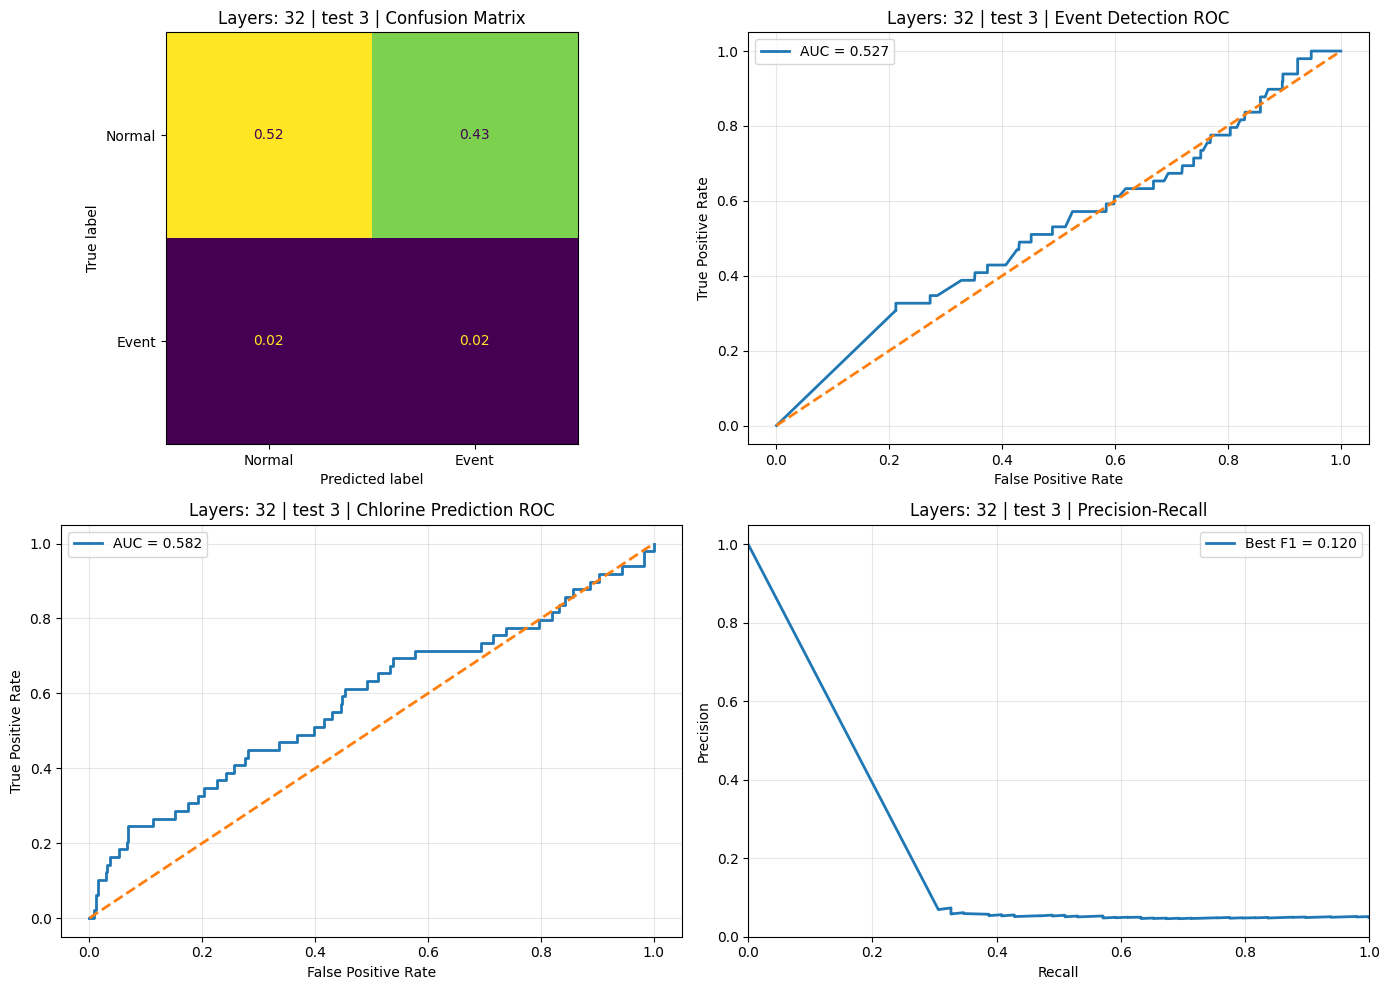


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_64-32/
Results for detector with hidden sizes: 64-32


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_no_cont17.npz,0.119760,0.698207,0.816327,0.816327,0.307853,-210600.0,334
scada_data_no_cont18.npz,0.072539,0.622510,0.571429,0.571429,0.374869,-216000.0,386
scada_data_no_cont19.npz,0.073684,0.709163,0.428571,0.428571,0.276440,-203400.0,285


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.088661,0.676627,0.605442,0.605442,0.319721,-210000.000000,335.000000
std,0.026939,0.047186,0.196103,0.196103,0.050276,6321.392252,50.507425


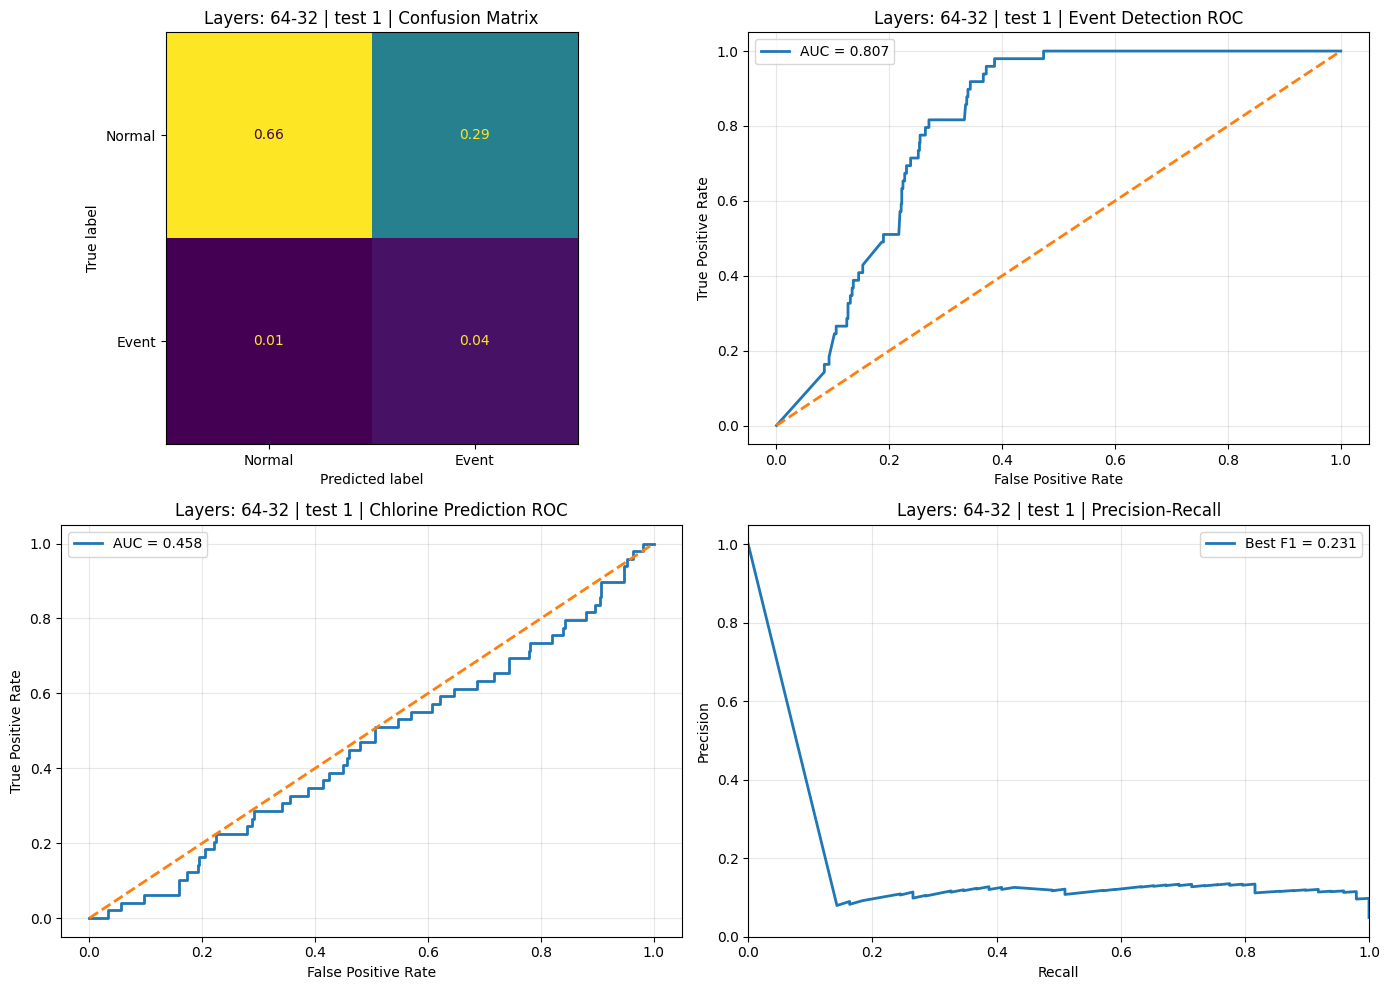

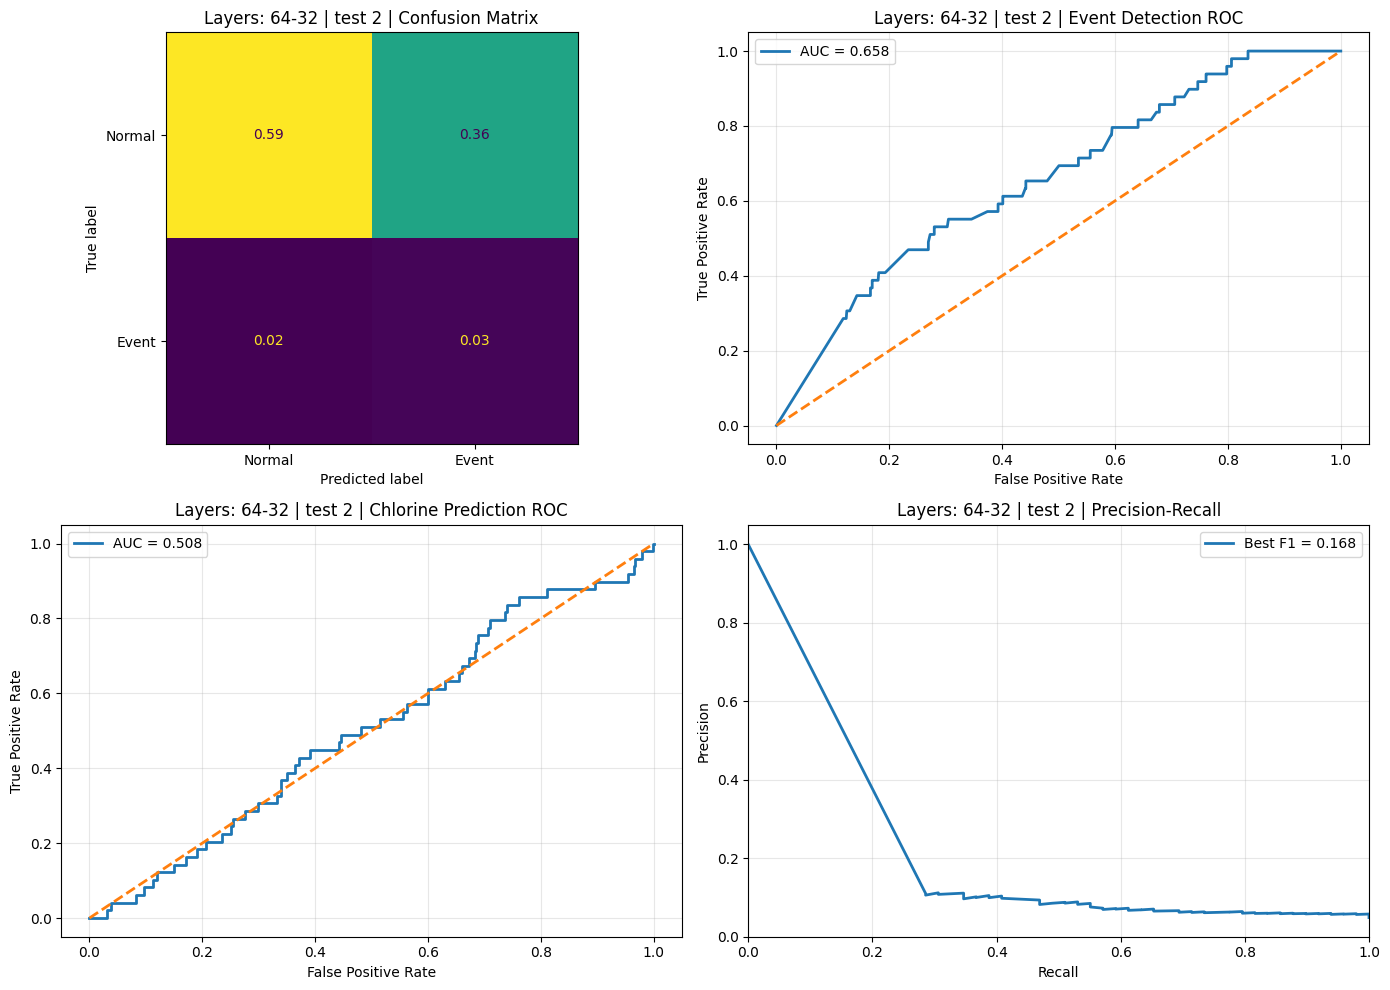

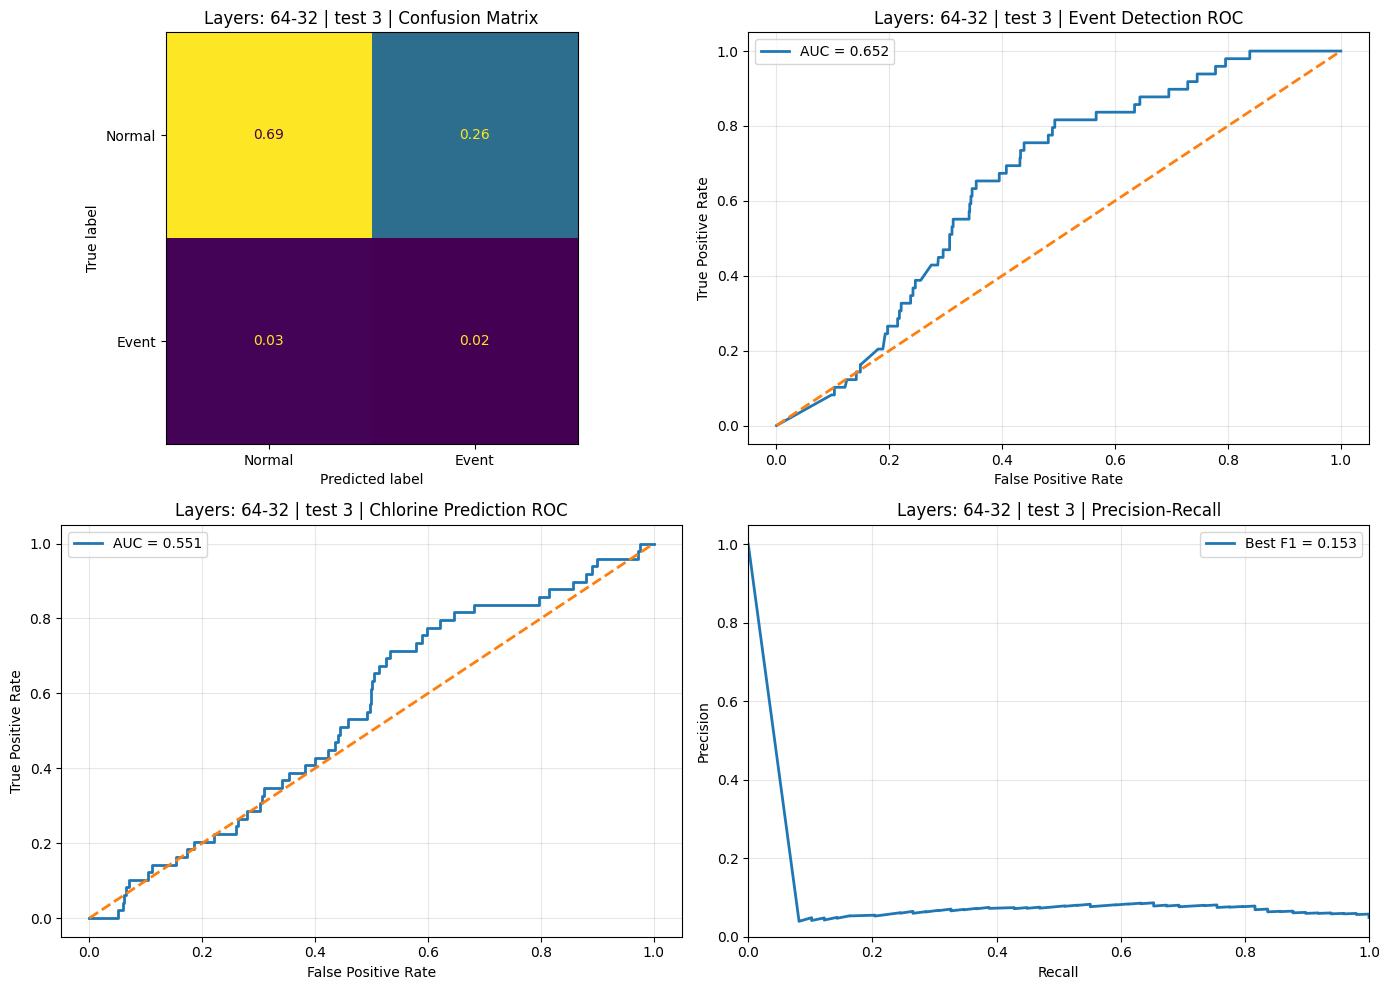


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64/
Results for detector with hidden sizes: 128-64


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_no_cont17.npz,0.092857,0.724104,0.530612,0.530612,0.265969,-214200.0,280
scada_data_no_cont18.npz,0.082540,0.689243,0.530612,0.530612,0.302618,-225000.0,315
scada_data_no_cont19.npz,0.088737,0.711155,0.530612,0.530612,0.279581,-226800.0,293


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.088045,0.708167,0.530612,0.530612,0.282723,-222000.000000,296.000000
std,0.005193,0.017621,0.000000,0.000000,0.018525,6814.690015,17.691806


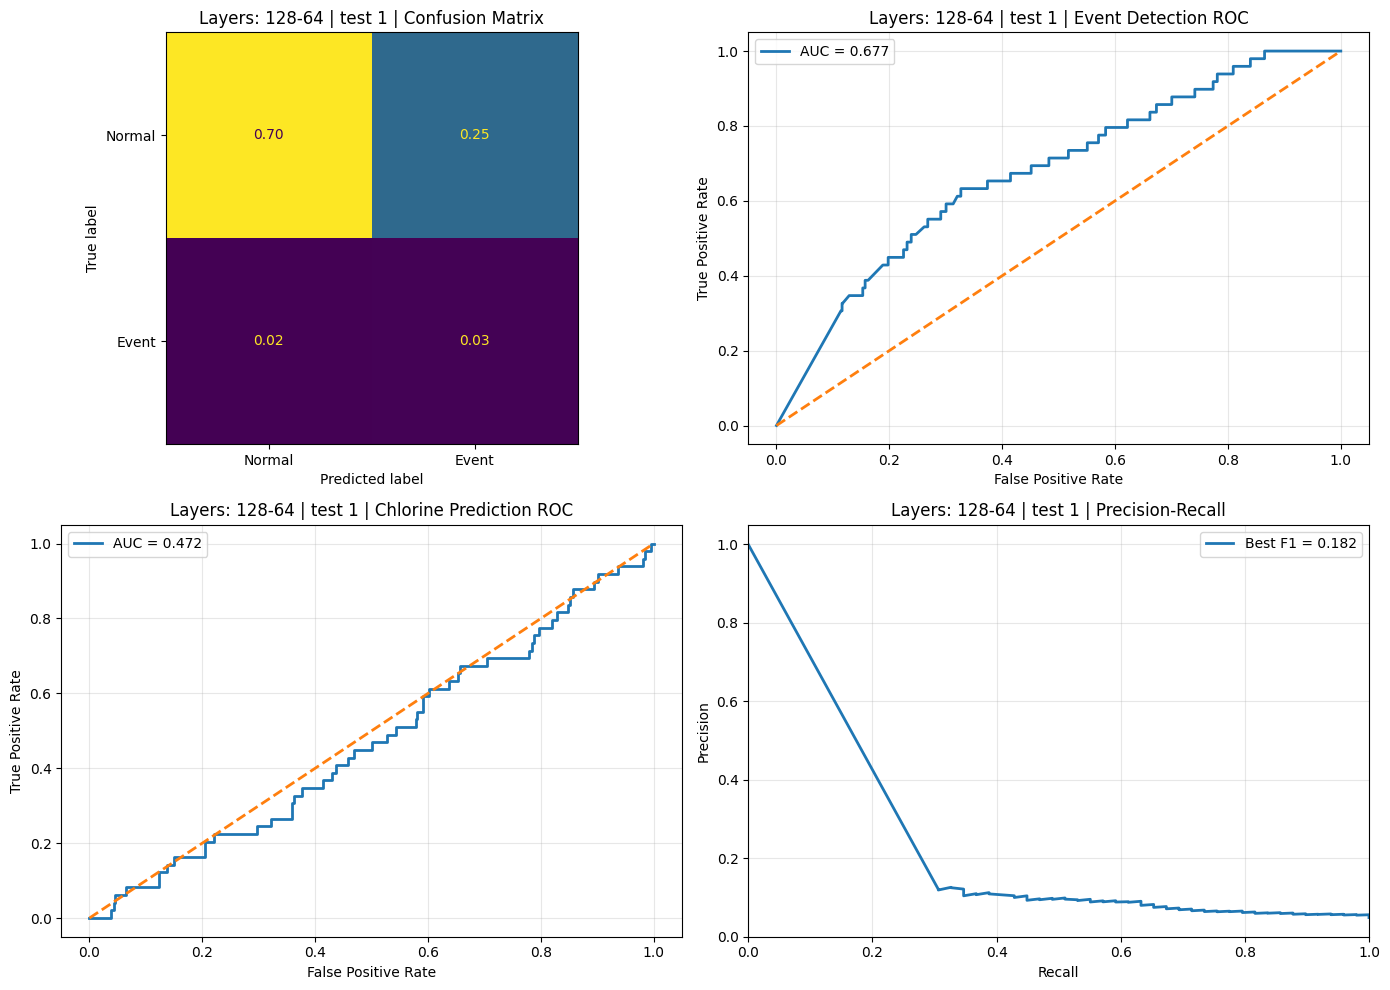

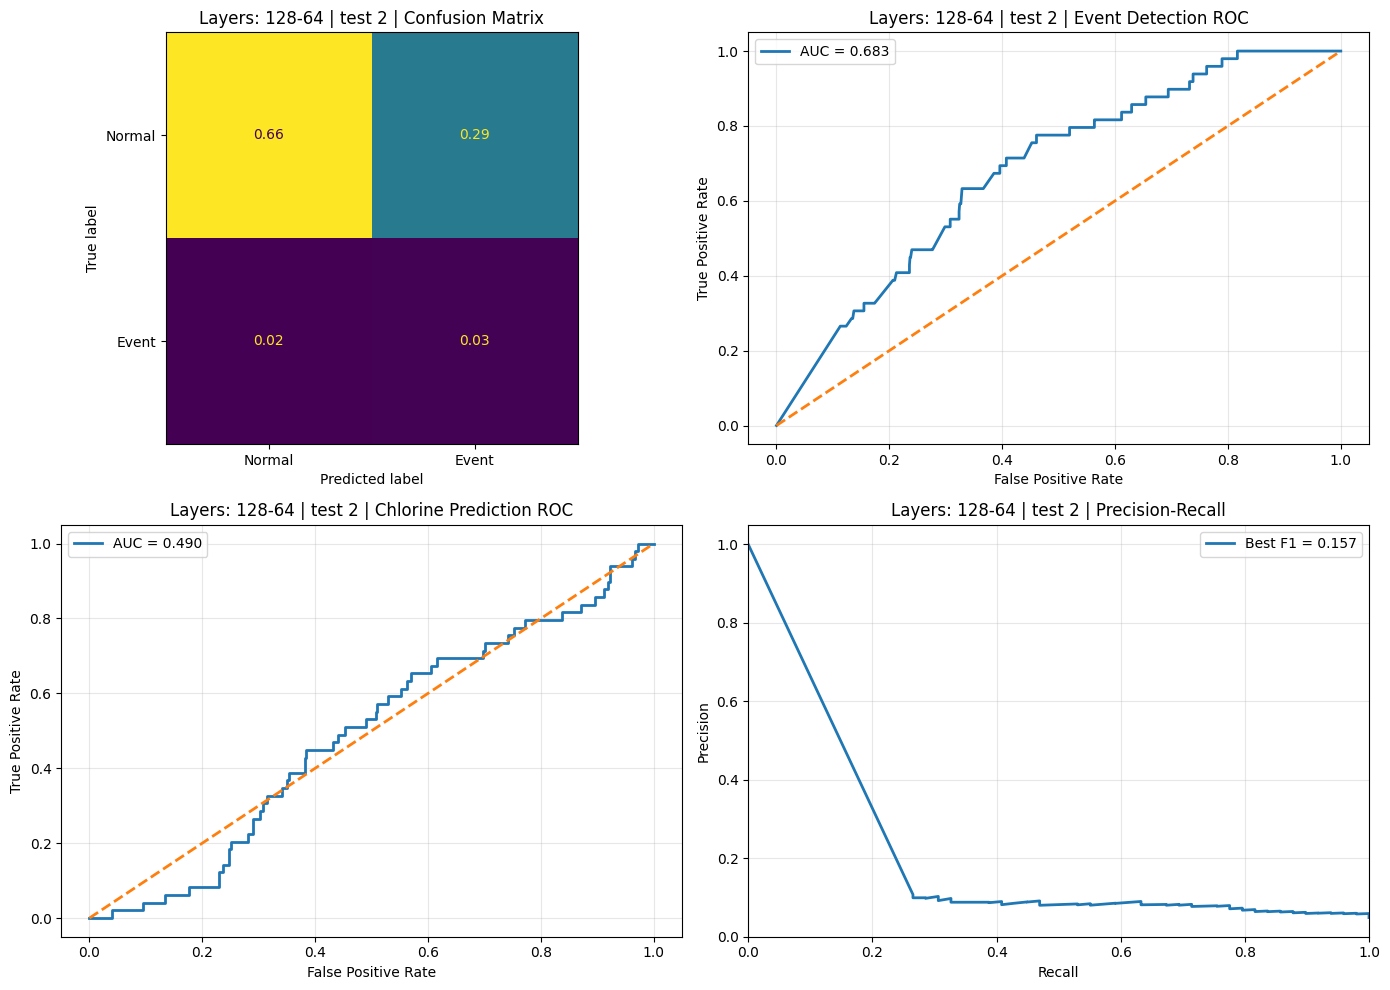

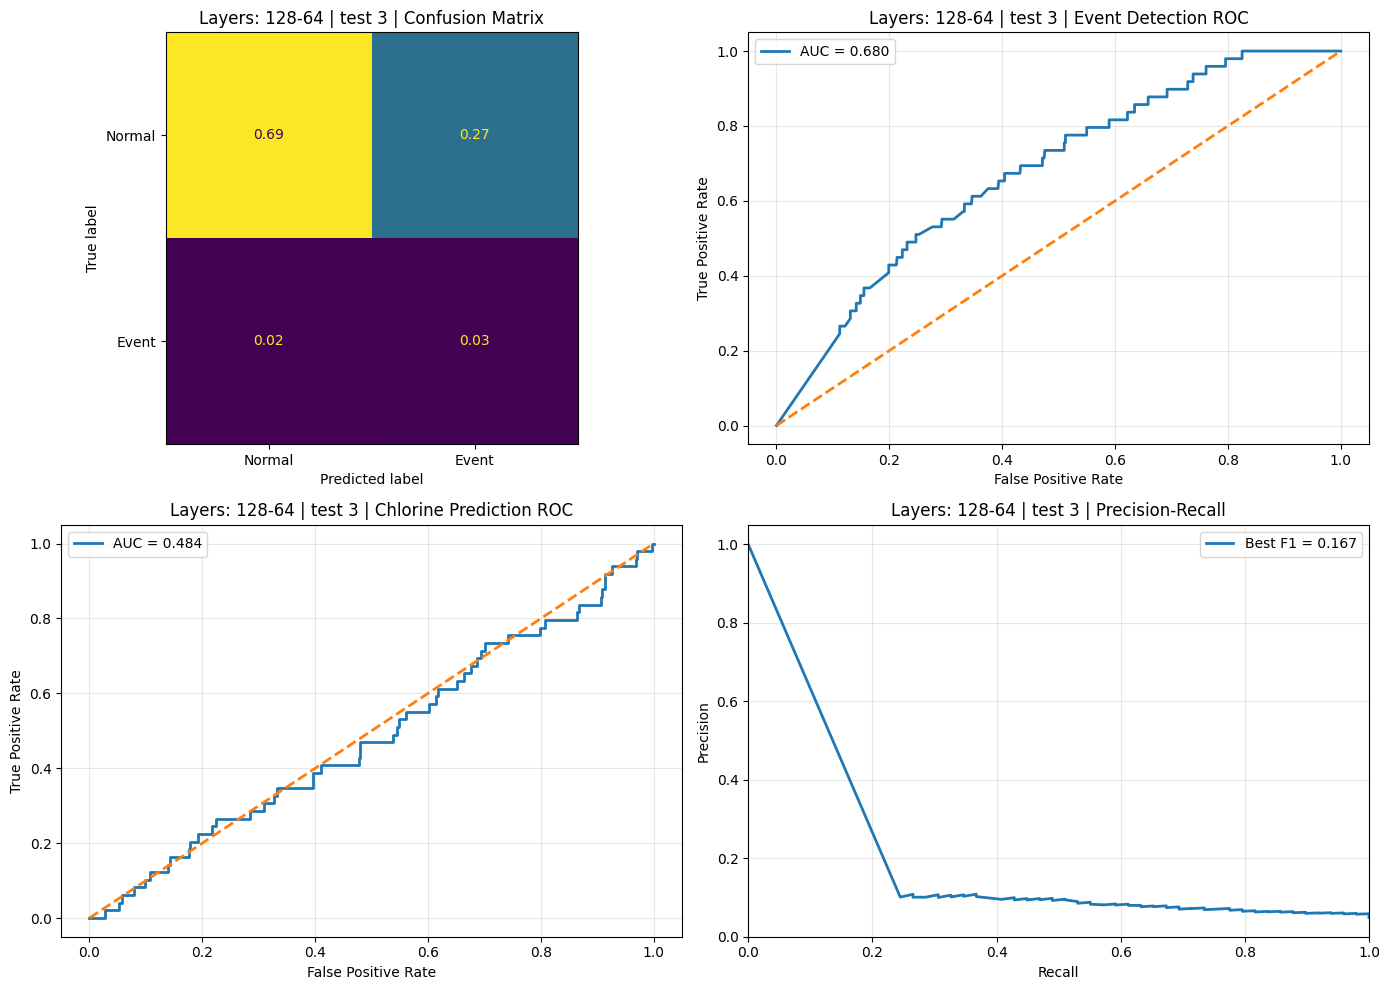


Detector successfully loaded from /Users/esther/dev/Arsenic-Detection/src/results/2026-06-29/detector_128-64-32/
Results for detector with hidden sizes: 128-64-32


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
scada_data_no_cont17.npz,0.066451,0.418327,0.836735,0.836735,0.603141,-228600.0,617
scada_data_no_cont18.npz,0.045283,0.471116,0.489796,0.489796,0.529843,-228600.0,530
scada_data_no_cont19.npz,0.054101,0.442231,0.632653,0.632653,0.567539,-219600.0,573


,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
mean,0.055278,0.443891,0.653061,0.653061,0.566841,-225600.000000,573.333333
std,0.010633,0.026434,0.174367,0.174367,0.036654,5196.152423,43.500958


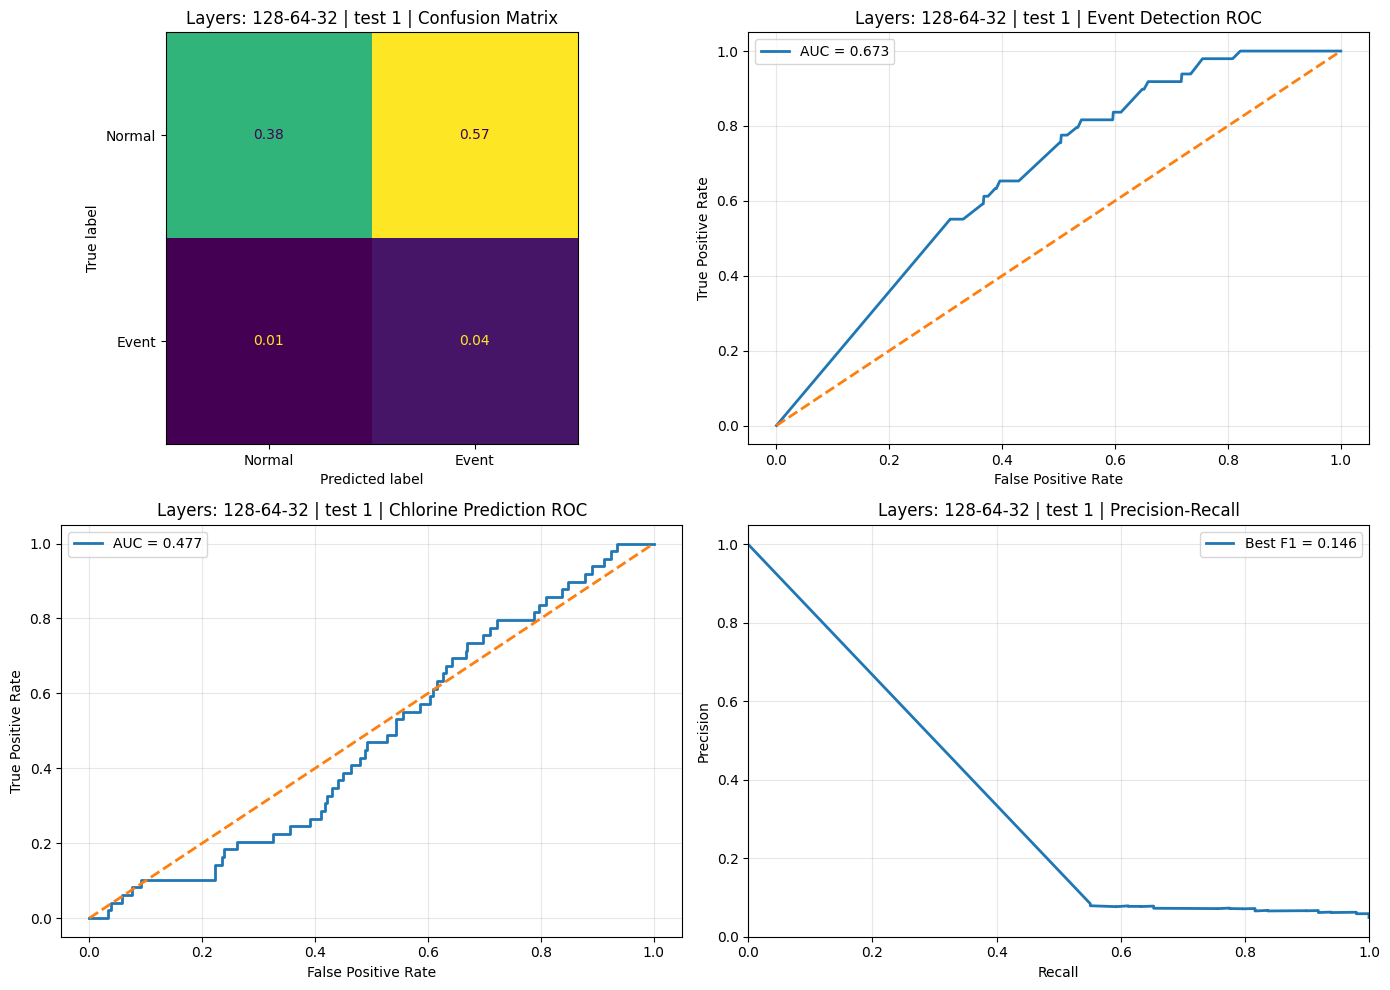

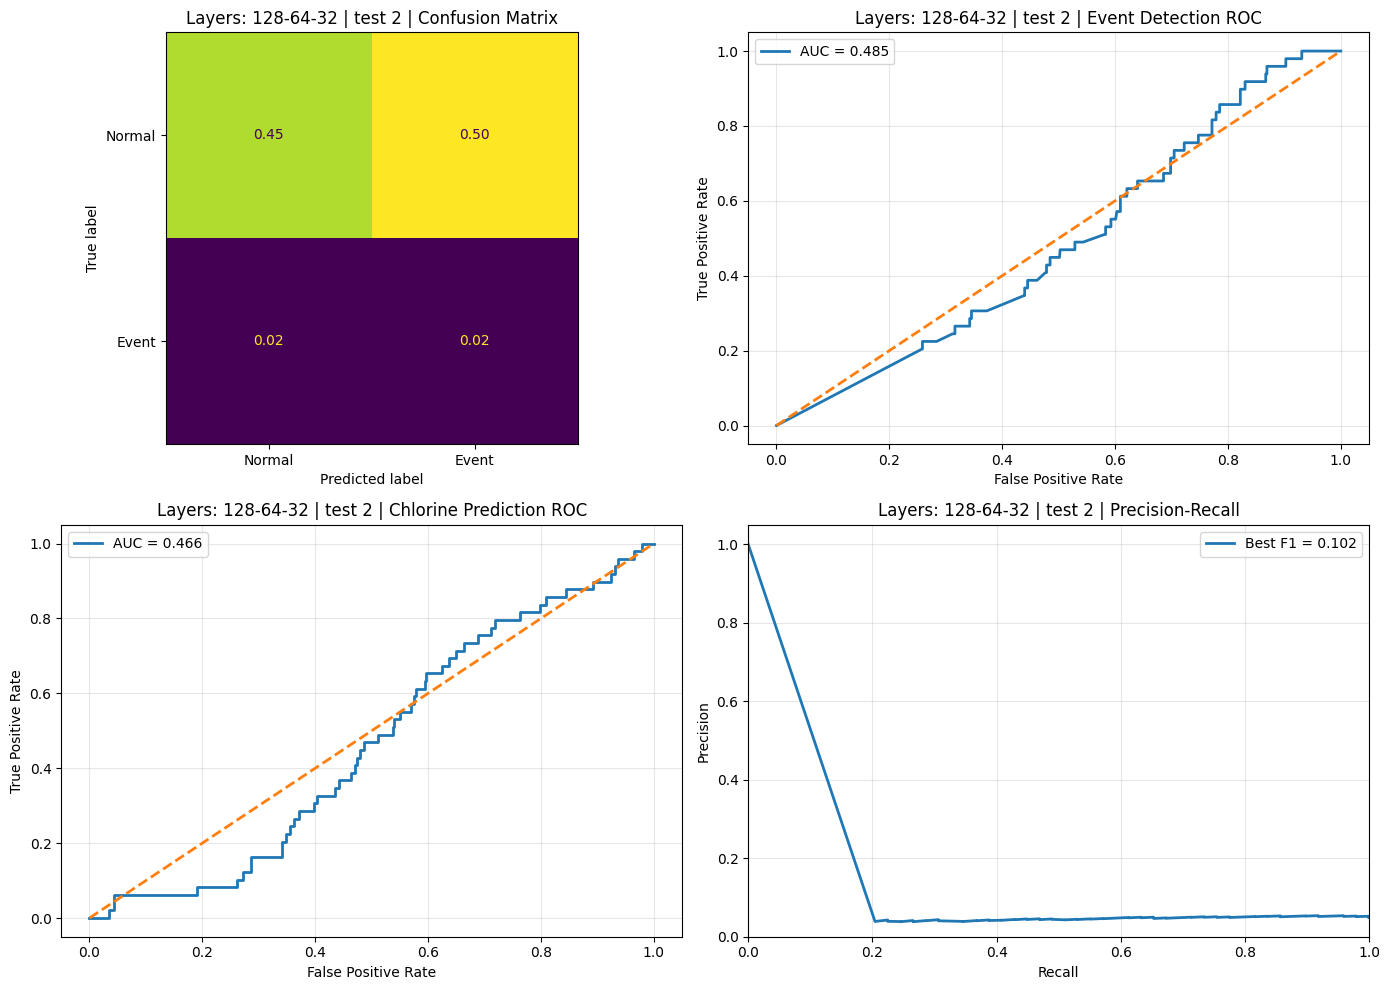

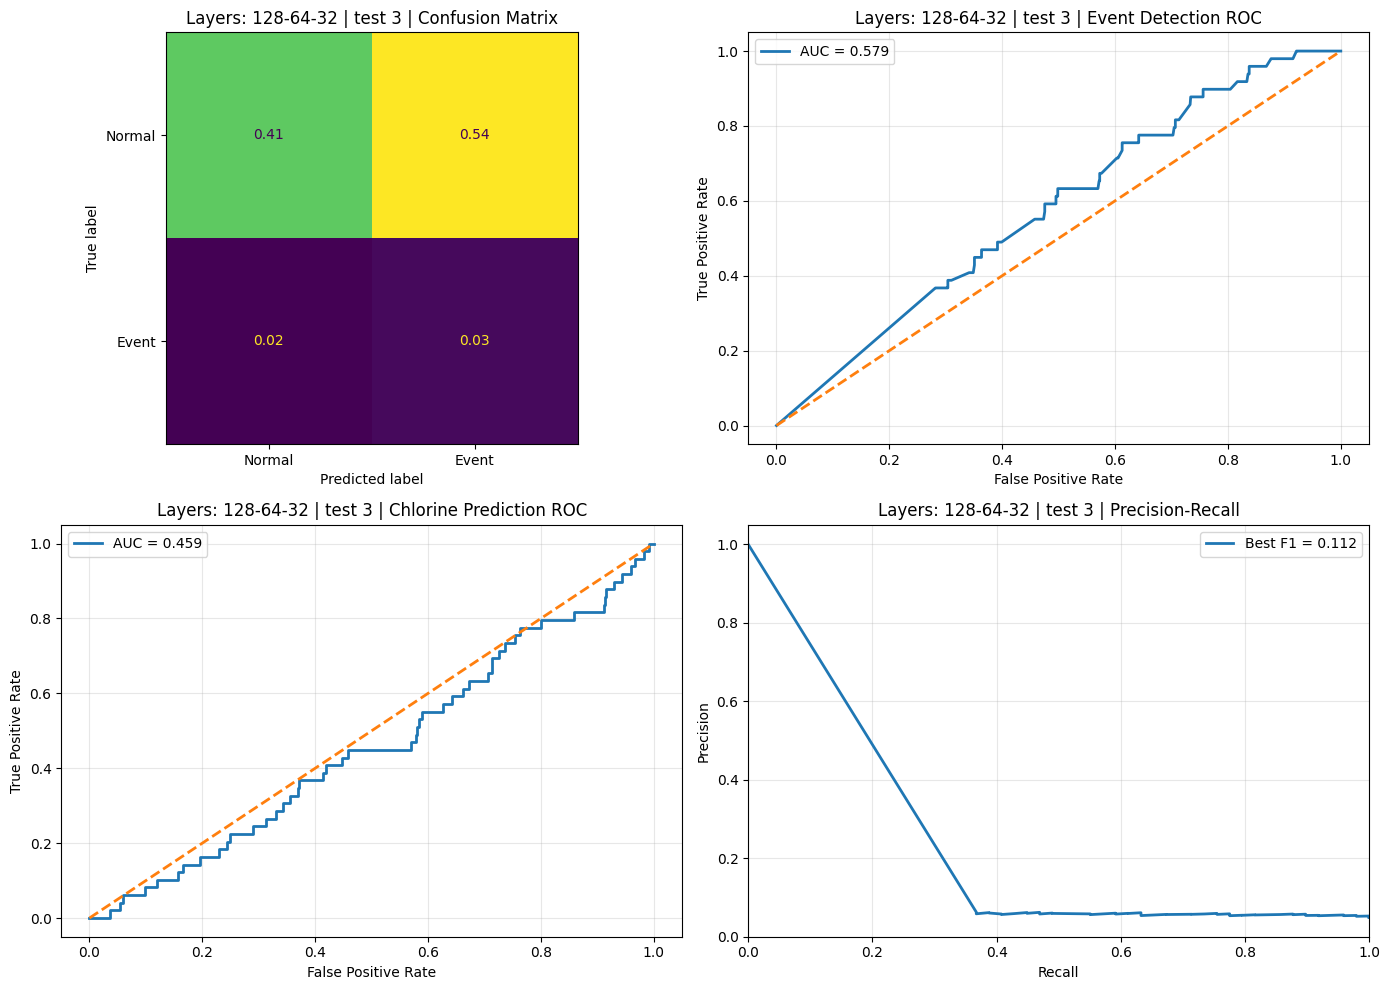

,precision,accuracy,probability_of_detection,recall,false_alarm_rate,detection_latency_seconds,alarms
hidden_sizes,,,,,,,
32,0.078712,0.660359,0.496599,0.496599,0.331239,-202200.0,340.666667
64-32,0.088661,0.676627,0.605442,0.605442,0.319721,-210000.0,335.000000
128-64,0.088045,0.708167,0.530612,0.530612,0.282723,-222000.0,296.000000
128-64-32,0.055278,0.443891,0.653061,0.653061,0.566841,-225600.0,573.333333


In [10]:
all_detector_summaries = []
# Use candidate_hidden_sizes to load the saved detectors and run tests on them.
for hidden_sizes in candidate_hidden_sizes:
    hidden_sizes_label = "-".join(map(str, hidden_sizes))
    detector = load_detector(
        directory=f"../results/2026-06-29/detector_{hidden_sizes_label}",
        device="mps",
    )

    selected_test_paths = test_paths[:3]
    results = [detector.detect(path) for path in selected_test_paths]

    print(f"Results for detector with hidden sizes: {hidden_sizes_label}")

    # Keep the three test sets separated.
    summary_df = pd.DataFrame(
        [result.summary() for result in results],
        index=[path.name for path in selected_test_paths],
    )
    display(summary_df)

    # Aggregate metrics across the three test sets.
    aggregated_summary = pd.DataFrame(
        [
            summary_df.mean(numeric_only=True),
            summary_df.std(numeric_only=True),
        ],
        index=["mean", "std"],
    )
    display(aggregated_summary)

    detector_summary = summary_df.mean(numeric_only=True).to_dict()
    detector_summary["hidden_sizes"] = hidden_sizes_label
    all_detector_summaries.append(detector_summary)

    # Plot each test set separately, because each DetectionResult has its own timeline.
    for i, result in enumerate(results):
        plot_metrics(
            result,
            title_prefix=f"Layers: {hidden_sizes_label} | test {i+1} | ",
        )

# Compare all detectors by their mean metrics.
all_detector_summaries_df = pd.DataFrame(all_detector_summaries).set_index("hidden_sizes")
display(all_detector_summaries_df)